# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Henry Fong]

**Date:** [09/02/2026]

In [ ]:
# Your Phase 1 solution to the problem goes here.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

"""
In the data table the price column has values that include comma 
such as 1,000 I used str.replace(',', '') to replace those comma
then astype(int) to convert those values into a integer ordered by
cheapest to most expensive
"""
path = "./data/airbnb_hw.csv"
df = pd.read_csv(path, low_memory=False)
df['price_clean'] = df['Price'].str.replace(',', '').astype(int)
df = df.sort_values(by="price_clean", ascending=True)
print(f"Missing values: {df['Price'].isnull().sum()}")
print(f"Cleaned Data: {df.head(5)}")

Missing values: 0
Cleaned Data:         Host Id  Host Since                                 Name  \
30087  41211757   8/11/2015         Private Room in Brooklyn, NY   
3120     751530   6/27/2011      Room in three-Bedroom Apartment   
19275  14381346   4/16/2014                           Small sofa   
9793    3991870  10/27/2012   1 Couch 8 min from Manhattan J\M\Z   
25139  25038105  12/20/2014  Cool Harlem Room available / shared   

      Neighbourhood  Property Type  Review Scores Rating (bin)  \
30087       Brooklyn     Apartment                         NaN   
3120        Brooklyn     Apartment                         NaN   
19275          Bronx         House                       100.0   
9793        Brooklyn     Apartment                        80.0   
25139      Manhattan         House                         NaN   

             Room Type  Zipcode  Beds  Number of Records  Number Of Reviews  \
30087     Private room  11219.0   1.0                  1                  0   
3120

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

"""
A large proportion of the data was missing however I do not know
if it was a concern as when I cross-tabulate I did not find any patterns
"""

path = "./data/mn_police_use_of_force.csv"
df = pd.read_csv(path, low_memory=False)
cleaned_df = df.dropna()
print(f"Amount of null values in subject injury: {df['subject_injury'].isnull().sum()}")
print(f"Proportion of values missing: {round(df['subject_injury'].isnull().sum()/df['subject_injury'].count(), 2)}")
print(f"Cross-tabulation (cleaned data with non cleaned data): {pd.crosstab(cleaned_df['subject_injury'], df['force_type'])}")
print(f"Cross-tabulation (cleaned data with cleaned data): {pd.crosstab(cleaned_df['subject_injury'], cleaned_df['force_type'])}")

Amount of null values in subject injury: 9848
Proportion of values missing: 3.2
Cross-tabulation (cleaned data with non cleaned data): force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1080                119        2   
Yes                 2          1243                 40        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal Projectile  \
subject_injury                                                                 
No                             33                 34                       1   
Yes                            44                 40                       2   

force_type      Police K9 Bite  Taser  
subject_injury                         
No                           2    149  
Yes                         43    166  
Cross-tabulation (cleaned data with cleaned data): force_type      Baton  Bodily Force  Chemical Irritant  Firearm 

Shark attack by year: fYear
1940.0     24
1941.0     27
1942.0     41
1943.0     28
1944.0     31
         ... 
2022.0     98
2023.0    109
2024.0     52
2025.0     69
2026.0     53
Name: Year, Length: 87, dtype: int64


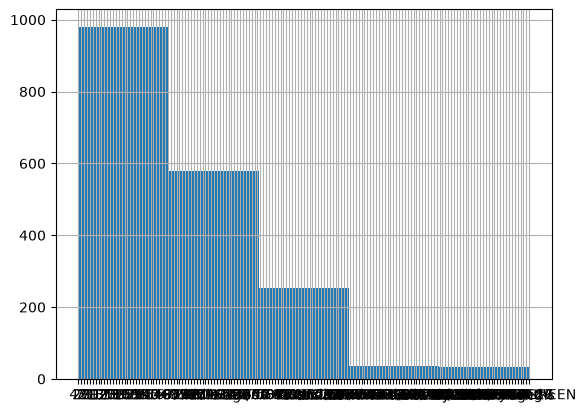

Proportion of male victim: Date              0.85
Year              0.85
Type              0.85
Country           0.85
State             0.81
Location          0.80
Activity          0.81
Name              0.85
Sex               0.85
Age               0.62
Injury            0.85
Fatal Y/N         0.80
Time              0.52
Species           0.54
Source            0.85
pdf               0.81
href formula      0.81
href              0.81
Case Number       0.81
Case Number.1     0.81
original order    0.81
Unnamed: 21       0.00
Unnamed: 22       0.00
dtype: float64
              Date    Year        Type           Country  \
0      26th August  2026.0  Unprovoked               USA   
1     23rd August   2026.0  Unprovoked               USA   
2      19th August  2026.0    Provoked    Reunion Island   
3      11th August  2026.0    Provoked           Ireland   
4       8th August  2026.0  Unprovoked               USA   
...            ...     ...         ...               ...   
5574   15

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

"""
From since 1940 the attacks have been increasing the proportion of victims that are male are .85
and the proportion of unprovoked attacks is .89
"""

path = "./data/GSAF5.xls"
df = pd.read_excel(path)
cleaned_df = df.dropna(how='all', axis=1)
cleaned_df = cleaned_df.query("Year >= 1940")
print(f"Shark attack by year: f{cleaned_df.astype('str').groupby('Year')['Year'].count()}")
cleaned_age_df = cleaned_df['Age'].replace('?', np.nan).dropna()
cleaned_age_df = cleaned_age_df.str.replace("'s", '').replace('+','')
chart = cleaned_age_df.hist(bins=5)
plt.show(chart)
print(f"Proportion of male victim: {round(cleaned_df.query("Sex == 'M'").count()/cleaned_df['Sex'].count(),2)}")
cleaned_type_df = cleaned_df.query("Type == 'Unprovoked' or Type == 'Provoked' or Type == 'Unknown'")
print(f"Proportion of unprovoked attacks: {round(cleaned_type_df.query("Type == 'Unprovoked'").count()/cleaned_type_df.count(),2)}")

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]